# SciPy: Statistics

## 1. Descriptive statisics

### 1.1. Basic statistics

In [63]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt

In [64]:
np.random.seed(0)
sample = np.random.randint(100, 1000, size=100)

In [65]:
# sample.min()
# sample.max()
# sample.sum()
sample.mean()

np.float64(570.69)

The [mean] (denoted $\mu$) or the [expected value] (denoted $E[\mathbf{x}]$) of a variable $\mathbf{x}=(x_1,x_2,\dots,x_N)$ is calculated by the formula:

$$\mu = \frac{1}{N} \sum_{n=1}^{N}{x_n}$$

[mean]: https://en.wikipedia.org/wiki/Arithmetic_mean
[expected value]: https://en.wikipedia.org/wiki/Expected_value

### 1.2. Variance
The [variance] of a random variable $\mathbf{x}$ is defined as:

$$\sigma^2 = \frac{1}{N}\sum_{n=1}^N{(x_n - \mu)}^2$$

where:
- $\sigma$ is the [standard deviation] of $\mathbf{x}$
- $\sigma^2$ is the variance of $\mathbf{x}$
- $\mu$ is the mean of $\mathbf{x}$
- $N$ is the size of $\mathbf{x}$

[variance]: https://en.wikipedia.org/wiki/Variance
[standard deviation]: https://en.wikipedia.org/wiki/Standard_deviation

In [66]:
import sys; sys.path.append('..')
from mlkit import np, stats

In [67]:
np.random.seed(0)
sample = np.random.randint(100, 1000, size=100)

In [68]:
sample.std()
# sample.var()

np.float64(270.7422647094465)

#### Unbiased variance
In many practical situations, $\mathbf{x}$ is just a sample and the true variance of the whole population is unknown. $\sigma_{\mathbf{x}}^2$ in this case is an [biased estimator], it usually underestimates the population variance. Correting for this bias yields:

$$\hat{\sigma}^2 = \frac{1}{N-1}\sum_{n=1}^N{(x_n - \mu)}^2$$

The use of the term $N-1$ is under [Bessel's correction]. The quantity $1$ subtracted from $N$ is the [degrees of freedom].

[biased estimator]: https://en.wikipedia.org/wiki/Bias_of_an_estimator
[Bessel's correction]: https://en.wikipedia.org/wiki/Bessel%27s_correction
[degrees of freedom]: https://en.wikipedia.org/wiki/Degrees_of_freedom_(statistics)

In [69]:
sample.var(ddof=1)

np.float64(74041.79181818181)

#### Variance and mean
The following formula demonstrates the relationship between the mean and the variance:

$$\sigma^2 = E\left[(\mathbf{x} - E[\mathbf{x}])^2\right] = E[\mathbf{x}^2] - E[\mathbf{x}]^2$$

In [70]:
np.mean(sample**2) - np.mean(sample)**2

np.float64(73301.37389999995)

### 1.3. Higher-order moments

#### Skewness
[Skewness](https://en.wikipedia.org/wiki/Skewness) is a measure of the asymmetry of a random variable about its mean. A skewness of $0$ indicates that the variable is symmetrically distributed. There are several approaches for calculating skewness (denoted $\gamma$); however, the Fisher's coefficient is the go-to one:

$$\gamma=\frac{m_3}{m_2^{3/2}}$$

where $\displaystyle{m_i=\frac{1}{N}\sum{(\mathbf{x}-\mu)^i}}$ is the $i^{th}$ [central moment](https://en.wikipedia.org/wiki/Central_moment). In estimating the population skewness, we multiply the biased formula by the factor $\displaystyle{\frac{\sqrt{N(N-1)}}{N-2}}$ where $N$ is the sample size.

In [71]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns

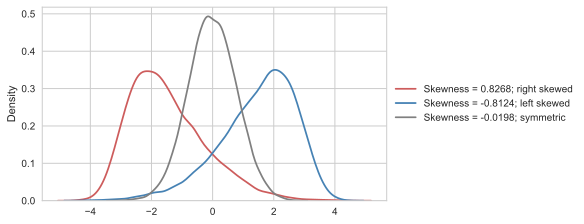

In [72]:
sample1 = stats.skewnorm(a=4, loc=-3, scale=2).rvs(size=10000, random_state=7)
sample2 = stats.skewnorm(a=-4, loc=3, scale=2).rvs(size=10000, random_state=7)
sample3 = stats.skewnorm(a=0, loc=0, scale=0.8).rvs(size=10000, random_state=7)

legend = [
    f'Skewness = {stats.skew(sample1):.4f}; right skewed',
    f'Skewness = {stats.skew(sample2):.4f}; left skewed',
    f'Skewness = {stats.skew(sample3):.4f}; symmetric'
]

fig, ax = plt.subplots(figsize=(8,3))
sns.kdeplot(sample1, color='indianred', ax=ax)
sns.kdeplot(sample2, color='steelblue', ax=ax)
sns.kdeplot(sample3, color='grey', ax=ax)
ax.legend(legend, bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

Note that the side of the skewness refers to the side of the longer tail. In the graph above, the red sample is said to be right skewed since the mass of its distribution is concentrated to the left, leading to a longer right tail.

In [73]:
skew1 = stats.skew(sample1)
skew2 = stats.skew(sample2)
print(f'{skew1 = :.4f}, {skew2 = :.4f}')

skew1 = 0.8268, skew2 = -0.8124


#### Kurtosis
[Kurtosis] is a measure of peakedness of a distribution. The calculation of kurtosis (denoted $\kappa$) is given by Fisher's definition:

$$\kappa=\frac{m_4}{m_2^2}-3$$

where $m_i$ is the $i^{th}$ [central moment] ($m_2$ is the variance). The quantity $3$ is subtracted from the result to give a skewness of $0$ for a normal distribution. When estimating the population kurtosis, we use the corrected formula:

$$\hat{\kappa}=\frac{N-1}{(N-2)(N-3)}\left[(N+1)\frac{m_4}{m_2^2}-3(N-1)\right]$$

[Kurtosis]: https://en.wikipedia.org/wiki/Kurtosis
[central moment]: https://en.wikipedia.org/wiki/Central_moment

In [74]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns

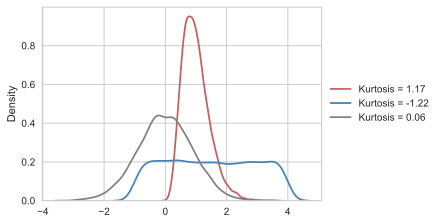

In [75]:
d1, d2 = 10, 1000
sample1 = stats.f(d1, d2).rvs(size=10000, random_state=7)
sample2 = stats.uniform(loc=-1, scale=5).rvs(size=10000, random_state=7)
sample3 = stats.norm(0, 0.9).rvs(size=10000, random_state=7)

fig, ax = plt.subplots(figsize=(6,3))
sns.kdeplot(sample1, color='indianred', ax=ax, label=f'Kurtosis = {stats.kurtosis(sample1):.2f}')
sns.kdeplot(sample2, color='steelblue', ax=ax, label=f'Kurtosis = {stats.kurtosis(sample2):.2f}')
sns.kdeplot(sample3, color='gray', ax=ax, label=f'Kurtosis = {stats.kurtosis(sample3):.2f}')
ax.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.show()

### 1.4. Quantiles
[Quantiles] are the $q-1$ cut points dividing a set of values into $q$ subsets of equal probability. Some common $q$-quantiles are [median] ($2$-quantile), [quartiles] ($4$-quantiles), deciles ($10$-quantiles) and [percentiles] ($100$-quantiles).

[Quantiles]: https://en.wikipedia.org/wiki/Quantile
[median]: https://en.wikipedia.org/wiki/Median
[quartiles]: https://en.wikipedia.org/wiki/Quartile
[percentiles]: https://en.wikipedia.org/wiki/Percentile

In [1]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns

In [77]:
np.random.seed(0)
sample = np.random.randint(100, 1000, size=100)

#### Median
There are 50% of data points smaller than the median and 50% of data points greater than the median.

In [78]:
np.median(sample)

np.float64(599.0)

#### Quartiles
$Q_1$, $Q_2$, $Q_3$ are the 3 quartiles that split our sample into 4 equal parts. There 25% of data points smaller than $Q_1$, 50% of the points smaller than $Q_2$ and 75% points smaller than $Q_3$. Notice that $Q_2$ is also known as the median. A [box plot] is usually used to visualize quartiles.

[box plot]: https://en.wikipedia.org/wiki/Box_plot

In [79]:
np.quantile(sample, [0.25, 0.5, 0.75])

array([300.25, 599.  , 807.5 ])

In [80]:
# unpacking quartiles
q1, q2, q3 = np.quantile(sample, [0.25, 0.5, 0.75])

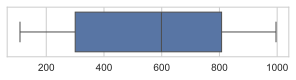

In [81]:
np.random.seed(0)
sample = np.random.randint(100, 1000, size=100)
q1, q2, q3 = np.quantile(sample, [0.25, 0.5, 0.75])

fig, ax = plt.subplots(figsize=(4,1))
sns.boxplot(x=sample, ax=ax)
plt.show()

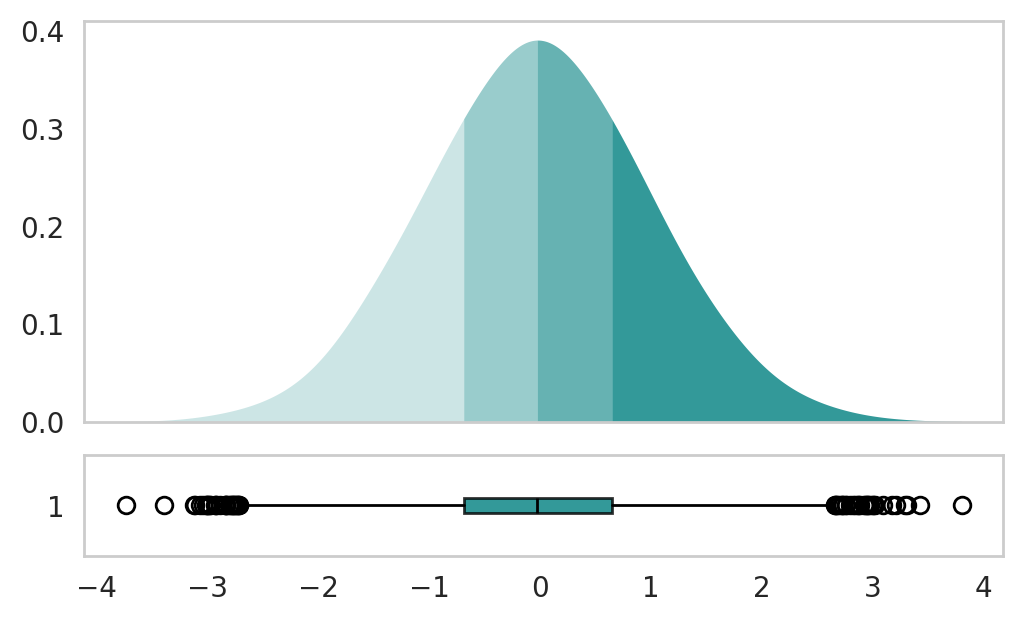

In [15]:
sample = stats.norm(loc=0, scale=1).rvs(10_000, random_state=0)
q1, q2, q3 = np.quantile(sample, [0.25, 0.5, 0.75])
kde = stats.gaussian_kde(sample)
kde.set_bandwidth(bw_method=kde.factor * 2)

fig, ax = plt.subplot_mosaic(
    [["kde"]]*4 + [["box"]],
    figsize=(5,3),
    sharex=True
)

cuts = [sample.min(), q1, q2, q3, sample.max()]
alphas = [0.2, 0.4, 0.6, 0.8]

for (lo, hi), alpha in zip(zip(cuts[:-1], cuts[1:]), alphas):
    x = np.linspace(lo, hi, 500)
    ax["kde"].fill_between(x, 0, kde(x), color="teal", alpha=alpha, linewidth=0)

ax["box"].boxplot(
    sample,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="teal", alpha=0.8),
    medianprops=dict(color="black"),
)

ax["kde"].set_ylim(0, None)
for a in ax.values():
    a.grid(False)

plt.show()


### 1.5. Correlation coefficient

In [82]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns

#### Covariance
First, we calculate the [covariance] (denoted $\sigma_{\mathbf{x},\mathbf{y}}$) of bivariate data, which is a measure of joint variability.

$$
\begin{aligned}
\sigma_{\mathbf{x},\mathbf{y}} 
&= \frac{1}{N} (\mathbf{x}-\mu_\mathbf{x})^\top (\mathbf{y}-\mu_\mathbf{y}) \\
&= E[(\mathbf{x}-E[\mathbf{x}])(\mathbf{y}-E[\mathbf{y}])]
\end{aligned}
$$

The `numpy.cov()` function returns the [covariance matrix] of $D$ variables: $\mathbf{x}_1,\mathbf{x}_2,\dots,\mathbf{x}_D$.

[covariance]: https://en.wikipedia.org/wiki/Covariance
[covariance matrix]: https://en.wikipedia.org/wiki/Covariance_matrix

In [83]:
np.random.seed(0)
x = np.random.randint(10, 100, size=10)
y = np.random.randint(10, 100, size=10)
z = np.random.randint(10, 100, size=10)

In [84]:
np.cov([x, y, z])

array([[ 659.1667, -128.1667,   93.5   ],
       [-128.1667,  664.7667,  -57.1   ],
       [  93.5   ,  -57.1   ,  823.4333]])

#### Correlation coefficient
[Correlation coefficient] (denoted $\rho_{\mathbf{x},\mathbf{y}}$) is the normalized version of covariance. By using the [Cauchy-Schwarz inequality], it's easy to proof that $\rho_{\mathbf{x},\mathbf{y}} \in [-1; 1]$. The closer the coefficient is to either -1 or 1, the stronger the correlation between the two variables.

$$\rho_{\mathbf{x},\mathbf{y}} = \frac{\sigma_{\mathbf{x},\mathbf{y}}}{\sigma_\mathbf{x} \sigma_\mathbf{y}}$$

The `numpy.corrcoef()` function returns the correlation coefficient matrix of $D$ variables: $\mathbf{x}_1,\mathbf{x}_2,\dots,\mathbf{x}_D$.

[Correlation coefficient]: https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
[Cauchy-Schwarz inequality]: https://en.wikipedia.org/wiki/Cauchy–Schwarz_inequality

In [5]:
np.random.seed(0)
x = np.random.randint(10, 100, size=10)
y = np.random.randint(10, 100, size=10)
z = np.random.randint(10, 100, size=10)

In [86]:
np.corrcoef([x, y, z])

array([[ 1.    , -0.1936,  0.1269],
       [-0.1936,  1.    , -0.0772],
       [ 0.1269, -0.0772,  1.    ]])

### 1.6. Probability plots
Probability plots are used to compare the distributions of two empirical datasets or to compare an empirical dataset with a theoretical distribution. Two popular techniques are the [Q-Q plot] (quantile-quantile plot) and the [P-P plot] (probability-probability plot). Q-Q plots are generally more popular in practice since their tails are easier to see that P-P plots.

[Q-Q plot]: https://en.wikipedia.org/wiki/Q%E2%80%93Q_plot
[P-P plot]: https://en.wikipedia.org/wiki/P%E2%80%93P_plot

In [2]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns, sm

#### Construction
Given a distribution with known parameters, the Q-Q plot for sample vs. model is constructed as follows:
- Sort the data: $x_1<x_2<\dots<x_N$
- For each rank $n=1..N$ assign plot positions $p_n=(n-0.5)/N$ (other choices exist)
- Compute theoretical quantiles $q_n=F^{-1}(p_n)$ where $F^{-1}$ is the inverse of the CDF
- Plot the points $(q_n, x_n)$
- Add a reference line for visual guidance

#### Implementation
The class [`ProbPlot`] from StatsModels is a single interface for producing both Q-Q plots and P-P plots. It can automatically find distribution parameters from the provided data without being specified. Then, you can call the `qqplot()` or `ppplot()` method to generate the corresponding plot.

[`ProbPlot`]: https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.ProbPlot.html

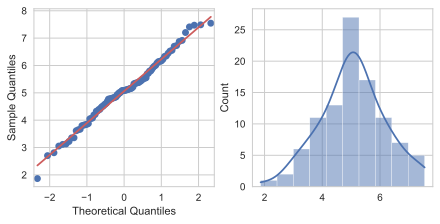

In [27]:
var = stats.norm(loc=0, scale=1).rvs(size=100, random_state=8) + 5
p = sm.ProbPlot(var, dist=stats.norm)

fig, ax = plt.subplots(figsize=(6,3), ncols=2)
p.qqplot(line='r', ax=ax[0])
ax[0].lines[1].set_color('indianred')
ax[1] = sns.histplot(var, edgecolor='w', kde=True)
plt.show()

## 2. Estimation 

In statistic, estimation is the process which calculates approximately the unknown parameters of population based on information of a sample. Population means and propotions are two common parameters in estimations


### 2.1. Point estimation 

 A point estimate of a population parameter is a single value of a statistic

#### Method of moments
Simple idea of moments method is let the population moments are equal to expected sample moments.
- [Biased/unbiased estimation]: the bias of an estimator is the difference between this estimator's expected value and the true value of the parameter being estimated. An estimator with zero bias is called unbiased. Statistic $\hat{\theta}$ of sample is called unbiased of parameter $\theta$ of population if: $E(\hat{\theta})=\theta$
- [Efficient estimation]: Statistic $\hat{\theta}$ of sample is called most efficiency estimate if it is a unbiased estimator and it has the smallest variance between all unbiased estimators was build on the same sample
- [Robust estimation]: In a large sample, if $\hat{\theta}$ converge to $\theta$ when $n \rightarrow \infty$ then it was called robust estimator

[Biased/unbiased estimation]: https://en.wikipedia.org/wiki/Bias_of_an_estimator
[Efficient estimation]: https://en.wikipedia.org/wiki/Efficiency_(statistics)
[Robust estimation]: https://en.wikipedia.org/wiki/Robust_statistics

#### Maximum likelihood

The idea of this method is estimating the unknown parameters which made the distribution best fit with the observed data. 

Assume we have $N$ observations $\mathbf{x} = (x_1, x_2, \dots ,x_N)$ that come with distribution $f$ and the vector of parameters $\mathbf{w}=(w_1, w_2,\dots, w_N)$. We have to find vector $\mathbf{w}$ to maximize the likelihood function $\hat{\mathbf{w}} = \arg\max L(\mathbf{w})$. The likelihood function is:

$$L(\mathbf{w}) = P(\mathbf{x}|\mathbf{w}) = P(x_1, x_2,\dots,x_N|\mathbf{w}) = \prod^N_{n=1} P(x_n|\mathbf{w})$$

To make the estimation of $\mathbf{w}$ easier, the log likelihood function is used in this case, then the parameters would be:

$$\log L(\mathbf{w})=\sum_{n=1}^N \log P(x_n|\mathbf{w})$$

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns

:::{admonition} Case
:class: tip
Having the spending data of 100 customers in the table below. Assume that money is normal distributed with confidence level 95%. Point estimate for mean of spending of all customer.
:::

In [0]:
df = pd.DataFrame({
    'spend':[10,14,18,22,26,30,34],
    'num_cus': [3,9,25,29,21,7,6]
})
df

In [0]:
df['sale'] = df['spend'] * df['num_cus']
df['sale'].sum() / df['num_cus'].sum()

### 2.2. Interval estimation 
An interval estimate is defined by two numbers, which the statistic lies between. The interval estimation of a statistic $\theta$ is found in the [confidence interval](https://en.wikipedia.org/wiki/Confidence_interval) $(\theta_1,\theta_2)$ where the probability that the statistic lies within the that interval is large enough to trust the result.

$$P(\theta_1<\theta<\theta_2)=1-\alpha$$

where:
- $\alpha$ is the significance level and $\gamma=1-\alpha$ is the confidence level
- $\theta_1$ and $\theta_2$ are lower and upper bounds, they are estimated base on a specific distribution

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, stats, plt, sns

#### Mean estimation
When estimating the mean of a large sample, the critical value follows a standard normal distribution: $c\sim\mathcal{N}(0,1)$. However when the the sample size is too small ($N\leq30$), a  t-distribution with $N-1$ degree of freedom is used instead to make sample variance closer to population variance: $c\sim\text{t}(N-1)$.

$$
\hat{\mu}-\epsilon
<\mu<
\hat{\mu}+\epsilon
\qquad\text{for }\epsilon=c_{\alpha/2}\frac{\hat{\sigma}}{\sqrt{N}}
$$

When estimating the difference in means of two samples (they should be large enough), we simply extend the previous case:

$$
(\hat{\mu}_1-\hat{\mu}_2)-\epsilon
<\mu_1-\mu_2<
(\hat{\mu}_1-\hat{\mu}_2)+\epsilon
\qquad\text{for }\epsilon=c_{\alpha/2}\sqrt{\frac{\hat{\sigma}_1^2}{N_1}+\frac{\hat{\sigma}_2^2}{N_2}}
$$

:::{admonition} Case
:class: tip
$20$ book stores have their mean of book price $135.8$ USD and variance $23.2$. With the confidence level of $95\%$, what is the range that market price of book should be in?
:::

In [0]:
alpha = 0.05
gamma = 1 - alpha
n, mean, var = 20, 135.8, 23.2

# instead of looking at the t table, we use Scipy to compute the critical value
crit = stats.t(n-1).isf(alpha/2)
eps = crit * np.sqrt(var/n)
lower = mean - eps
upper = mean + eps

print(f'{gamma:.0%} confidence interval is ({lower:.2f}, {upper:.2f})')

:::{admonition} Case
:class: tip
A random sample of $120$ students yields mean GPA $2.71$ with standard deviation $0.43$. Construct a $90\%$ confidence interval for mean GPA of all students in that university.
:::

In [0]:
gamma = 0.9
alpha = 1 - gamma
n, mean, std = 120, 2.71, 0.43

crit = stats.norm().isf(alpha/2)
eps = crit * std / np.sqrt(n)
lower = mean - eps
upper = mean + eps

print(f'{gamma:.0%} confidence interval is ({lower:.2f}, {upper:.2f})')

#### Proportion estimation
When estimating the proportion of a population given sample proportion ($\hat{p}$), we use a critical value follows a standard normal distribution: $c\sim\mathcal{N}(0,1)$

$$
\hat{p}-\epsilon
<p<
\hat{p}+\epsilon
\qquad\text{for }\epsilon=c_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{N}}
$$

Like interval estimation for mean, we can also extend proportion estimation for the case of two samples:

$$
(\hat{p}_1-\hat{p}_2)-\epsilon
<p_1-p_2<
(\hat{p}_1-\hat{p}_2)+\epsilon
\qquad\text{for }\epsilon=c_{\alpha/2}\sqrt{\frac{\hat{p}_1(1-\hat{p}_1)}{N_1}+\frac{\hat{p}_2(1-\hat{p}_2)}{N_2}}
$$

:::{admonition} Case
:class: tip
To estimate the proportion of students at a large college who are female, a random sample of $N=120$ students is selected. There are $69$  female students in the sample. Construct a $90\%$  confidence interval for the proportion of all students at the college who are female.
:::

In [0]:
gamma = 0.9
alpha = 1-gamma
n, p = 120, 69/120

crit = stats.norm().isf(alpha/2)
eps = crit * np.sqrt(p * (1-p) / n)
lower = p - eps
upper = p + eps

print(f'{gamma:.0%} confidence interval is ({lower:.2f}, {upper:.2f})')

#### Variance estimation
When estimating population variance, the critical value follows a chi-squared distribution with $N-1$ degrees of freedom: $c\sim\chi^2(N-1)$.

$$
\frac{N-1}{c_{\alpha/2}}\hat{\sigma}^2
<\sigma^2<
\frac{N-1}{c_{1-\alpha/2}}\hat{\sigma}^2
$$

To estimate the ratio of two variances, we use a critical value that follows an F-distribution with $N-1$ and $N-2$ degrees of freedom: $c\sim \text{F}(N_1-1,N_2-1)$.

$$
\frac{1}{c_{\alpha/2}}\frac{\hat{\sigma}_1^2}{\hat{\sigma}_2^2}
<\frac{\sigma_1^2}{\sigma_2^2}<
c_{\alpha/2}\frac{\hat{\sigma}_1^2}{\hat{\sigma}_2^2}
$$

:::{admonition} Case
:class: tip
A candy company targets to produces candy packs of exactly $52$ grams. In attemp to estimate the variance of all packs, a quality control manager takes a random sample of $10$ packs, it yields the variance of $4.2$. Use that sample to derive a $95\%$ confidence interval for $\sigma$.
:::

In [0]:
gamma = 0.95
alpha = 1 - gamma
n, var = 10, 4.2

dist = stats.chi2(n-1)
crit1, crit2 = dist.isf(alpha/2), dist.isf(1-alpha/2)
lower = (n-1) * var / crit1
upper = (n-1) * var / crit2

# confidence interval for standard deviation
lower, upper = np.sqrt(lower), np.sqrt(upper)

print(f'{gamma:.0%} confidence interval is ({lower:.2f}, {upper:.2f})')

:::{admonition} Case
:class: tip
Two spider species, deinopis and menneus, coexist in eastern Australia. Collect a sample of $10$ preys for each species, we obtained the standard deviations of prey size (in millimeters) are $2.51$ and $1.9$, respectively. Estimate, with $95\%$ confidence, the ratio of two population variances.
:::

In [0]:
gamma = 0.95
alpha = 1 - gamma
n1, var1 = 10, 2.51**2
n2, var2 = 10, 1.9**2

crit = stats.f(n1-1, n2-1).isf(alpha/2)
lower = var1 / var2 / crit
upper = var1 / var2 * crit

print(f'{gamma:.0%} confidence interval is ({lower:.2f}, {upper:.2f})')

## Resources
- stat.psu.edu - [Introduction to Mathematical Statistics](https://online.stat.psu.edu/stat415/section/6)